Libraries imported successfully!
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset loaded!
Training images shape: (60000, 28, 28) | Training labels shape: (60000,)
Test images shape: (10000, 28, 28) | Test labels shape: (10000,)


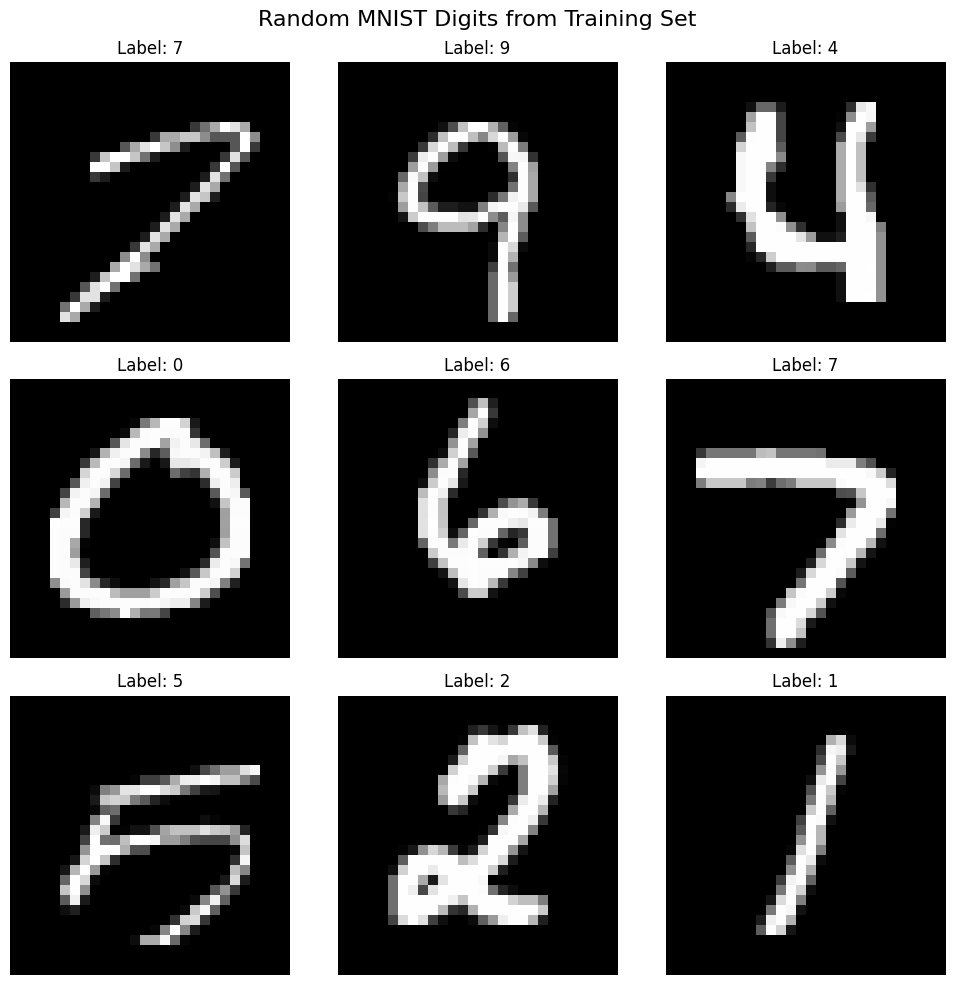


Preprocessing completed:
Pixel range after normalization: [0.0, 1.0]
One-hot encoded labels shape (train): (60000, 10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8285 - loss: 0.5613 - val_accuracy: 0.9527 - val_loss: 0.1665
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9261 - loss: 0.2560 - val_accuracy: 0.9632 - val_loss: 0.1199
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9411 - loss: 0.1998 - val_accuracy: 0.9712 - val_loss: 0.0974
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9516 - loss: 0.1653 - val_accuracy: 0.9750 - val_loss: 0.0830
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9569 - loss: 0.1460 - val_accuracy: 0.9740 - val_loss: 0.0803
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9611 - loss: 0.1324 - val_accuracy: 0.9768 - val_loss: 0.0760
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9636 - loss: 0.1216 - val_accuracy: 0.9808 - val_loss: 0.0714
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9654 - loss: 0.

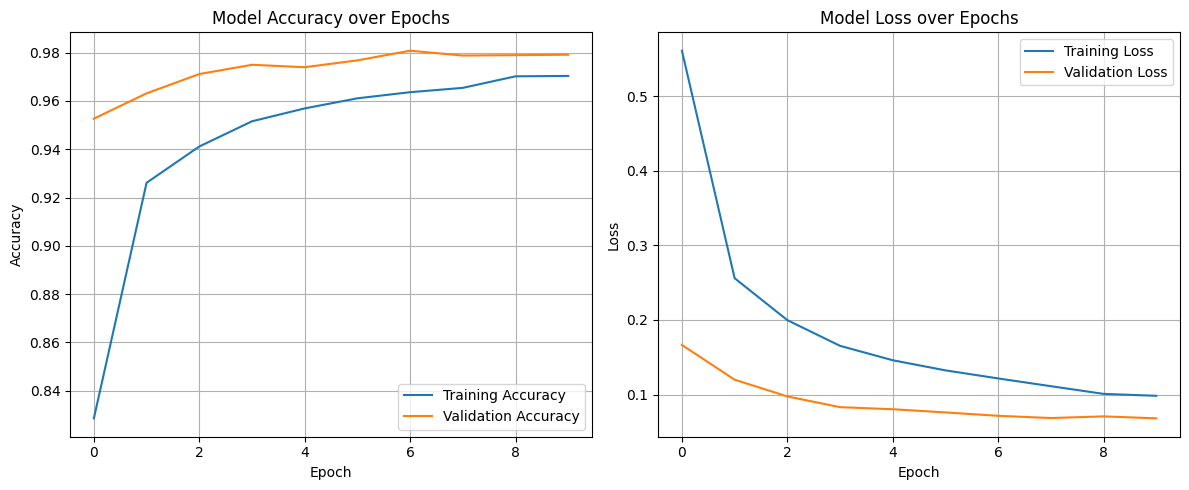

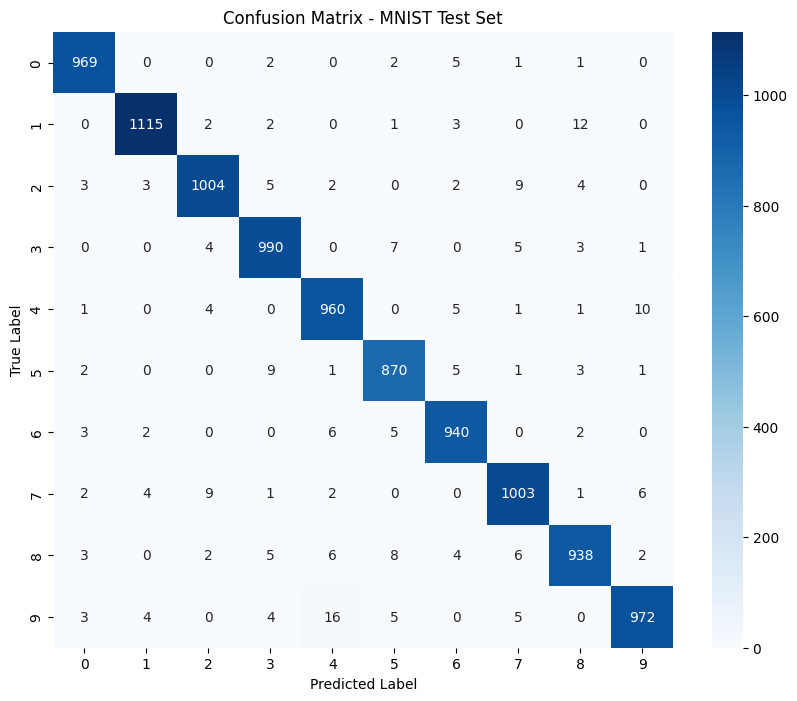


Classification Report:
              precision    recall  f1-score   support

           0     0.9828    0.9888    0.9858       980
           1     0.9885    0.9824    0.9854      1135
           2     0.9795    0.9729    0.9762      1032
           3     0.9725    0.9802    0.9763      1010
           4     0.9668    0.9776    0.9722       982
           5     0.9688    0.9753    0.9721       892
           6     0.9751    0.9812    0.9781       958
           7     0.9728    0.9757    0.9743      1028
           8     0.9720    0.9630    0.9675       974
           9     0.9798    0.9633    0.9715      1009

    accuracy                         0.9761     10000
   macro avg     0.9759    0.9760    0.9759     10000
weighted avg     0.9761    0.9761    0.9761     10000


Model saved successfully as 'mnist_ann_model.keras'
Reloaded model test accuracy: 0.9761


In [1]:
## Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

## Step 2: Load the MNIST Dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset loaded!")
print(f"Training images shape: {X_train.shape} | Training labels shape: {y_train.shape}")
print(f"Test images shape: {X_test.shape} | Test labels shape: {y_test.shape}")

## Step 3: Visualize 9 Random Images with Labels
plt.figure(figsize=(10, 10))
for i in range(9):
    idx = np.random.randint(0, len(X_train))
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.title(f"Label: {y_train[idx]}")
    plt.axis('off')
plt.suptitle("Random MNIST Digits from Training Set", fontsize=16)
plt.tight_layout()
plt.show()

## Step 4: Preprocess the Data
# Normalize pixel values to [0, 1]
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-hot encode the labels
y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("\nPreprocessing completed:")
print(f"Pixel range after normalization: [{X_train.min():.1f}, {X_train.max():.1f}]")
print(f"One-hot encoded labels shape (train): {y_train_cat.shape}")

## Step 5: Build the Artificial Neural Network Model
model = Sequential([
    Flatten(input_shape=(28, 28)),           # Input layer
    Dense(128, activation='relu'),           # Hidden layer 1
    Dropout(0.3),                            # Regularization
    Dense(64, activation='relu'),            # Hidden layer 2
    Dropout(0.3),                            # Regularization
    Dense(10, activation='softmax')          # Output layer
])

model.summary()

## Step 6: Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

## Step 7: Train the Model
print("\nStarting training...\n")
history = model.fit(X_train, y_train_cat,
                    epochs=10,
                    batch_size=128,
                    validation_split=0.1,
                    verbose=1)

## Step 8: Evaluate on Test Set
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\n🎯 Final Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

## Step 9: Visualize Training History
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Step 10: Predictions & Confusion Matrix
y_pred = model.predict(X_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - MNIST Test Set')
plt.show()

## Step 11: Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, digits=4))

## Step 12: Save the Model in Modern Keras Format (.keras)
model.save("mnist_ann_model.keras")
print("\nModel saved successfully as 'mnist_ann_model.keras'")

# Optional: Load and verify
reloaded_model = load_model("mnist_ann_model.keras")
reloaded_loss, reloaded_acc = reloaded_model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Reloaded model test accuracy: {reloaded_acc:.4f}")